# Single Participant Analysis - P004

**Time-Delay Embedding Analysis of Locomotor Resilience**

This notebook demonstrates the complete TDE pipeline for analyzing postural resilience during perturbed gait.

**Author:** Victor SALVAT  
**Date:** 2026-03-31  
**Participant:** 004 (Young adult)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import sys
from scipy.signal import find_peaks, savgol_filter

sys.path.append('../sources/python')

from load_data import load_pmocap_file
from preprocessing import preprocess_pipeline
from time_delay_embedding import compute_ami, compute_fnn, phase_space_reconstruction
from state_space import create_reference_trajectory, compute_euclidean_distances, compute_torus_thresholds
from perturbation_detection import detect_beeps, detect_perturbations
from resilience_metrics import compute_all_perturbation_metrics
from visualization import generate_all_figures

plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

print("✓ Setup complete")

✓ Setup complete


In [2]:
data = load_pmocap_file('../data/antoine/004_Cued.mat')
print("\n✓ Data loaded")

Loading pMOCAP file: 004_Cued.mat
    Sacrum markers: 4 × 192000 samples
    Occluded samples: 23350 (3.04%)
    Analog signal: 240065 samples at 500.0 Hz
  ✓ Loaded successfully
    Participant: 004
    Duration: 480.00 s
    Sacrum fs: 400.0 Hz
    Analog fs: 500.0 Hz

✓ Data loaded


In [3]:
preprocessed = preprocess_pipeline(
    data['sacrum'],
    apply_emd=True,
    downsample_factor=4
)

sacrum_z = preprocessed['sacrum_z']
time_signal = preprocessed['time']
fs = 100

print(f"\n✓ Signal: {len(sacrum_z)} samples at {fs} Hz")


PREPROCESSING PIPELINE

[1/5] Computing barycenter...
  Barycenter computed: (192000, 3)
    X range: [-1283.16, 1197.02] mm
    Y range: [-3341.05, 3243.84] mm
    Z range: [-50.68, 48.79] mm

[2/5] EMD decomposition...
  Applying EMD decomposition...


    Decomposed into 14 IMFs
    Combined IMFs [3, 4, 5, 6, 7, 8]
    Reconstructed signal: mean=0.58, std=16.43

[3/5] Butterworth filtering...
  Butterworth filter applied: 4th order, fc=5.0 Hz

[4/5] Downsampling...
  Downsampled by factor 4: 192000 → 48000 samples

[5/5] Creating time vector...

PREPROCESSING COMPLETE
  Original: 192000 samples @ 400.0 Hz
  Final: 48000 samples @ 100.0 Hz
  Duration: 479.99 seconds


✓ Signal: 48000 samples at 100 Hz


In [4]:
tau_optimal, ami_values = compute_ami(sacrum_z, max_lag=100)
dim_optimal, fnn_rates = compute_fnn(sacrum_z, max_dim=10, tau=tau_optimal)

print(f"\n✓ TDE parameters: τ={tau_optimal}, dim={dim_optimal}")


✓ TDE parameters: τ=19, dim=5


In [5]:
state_space = phase_space_reconstruction(sacrum_z, tau_optimal, dim=3)
print(f"\n✓ State-space: {state_space.shape}")


✓ State-space: (47962, 3)


  Detected 895 beeps
    First beep: 0.50 s
    Last beep: 479.86 s

  Baseline cadence: 111.9 bpm
  Baseline interval: 0.536 s
  Detection bounds: [0.456, 0.617] s

  Perturbations detected:
    Slow: t = 173.54 s (beep #323)
    Fast: t = 354.61 s (beep #659)

✓ Perturbations:
  Slow: 173.54s
  Fast: 354.61s
  Saved: ../results/figures/004_perturbation_detection.png


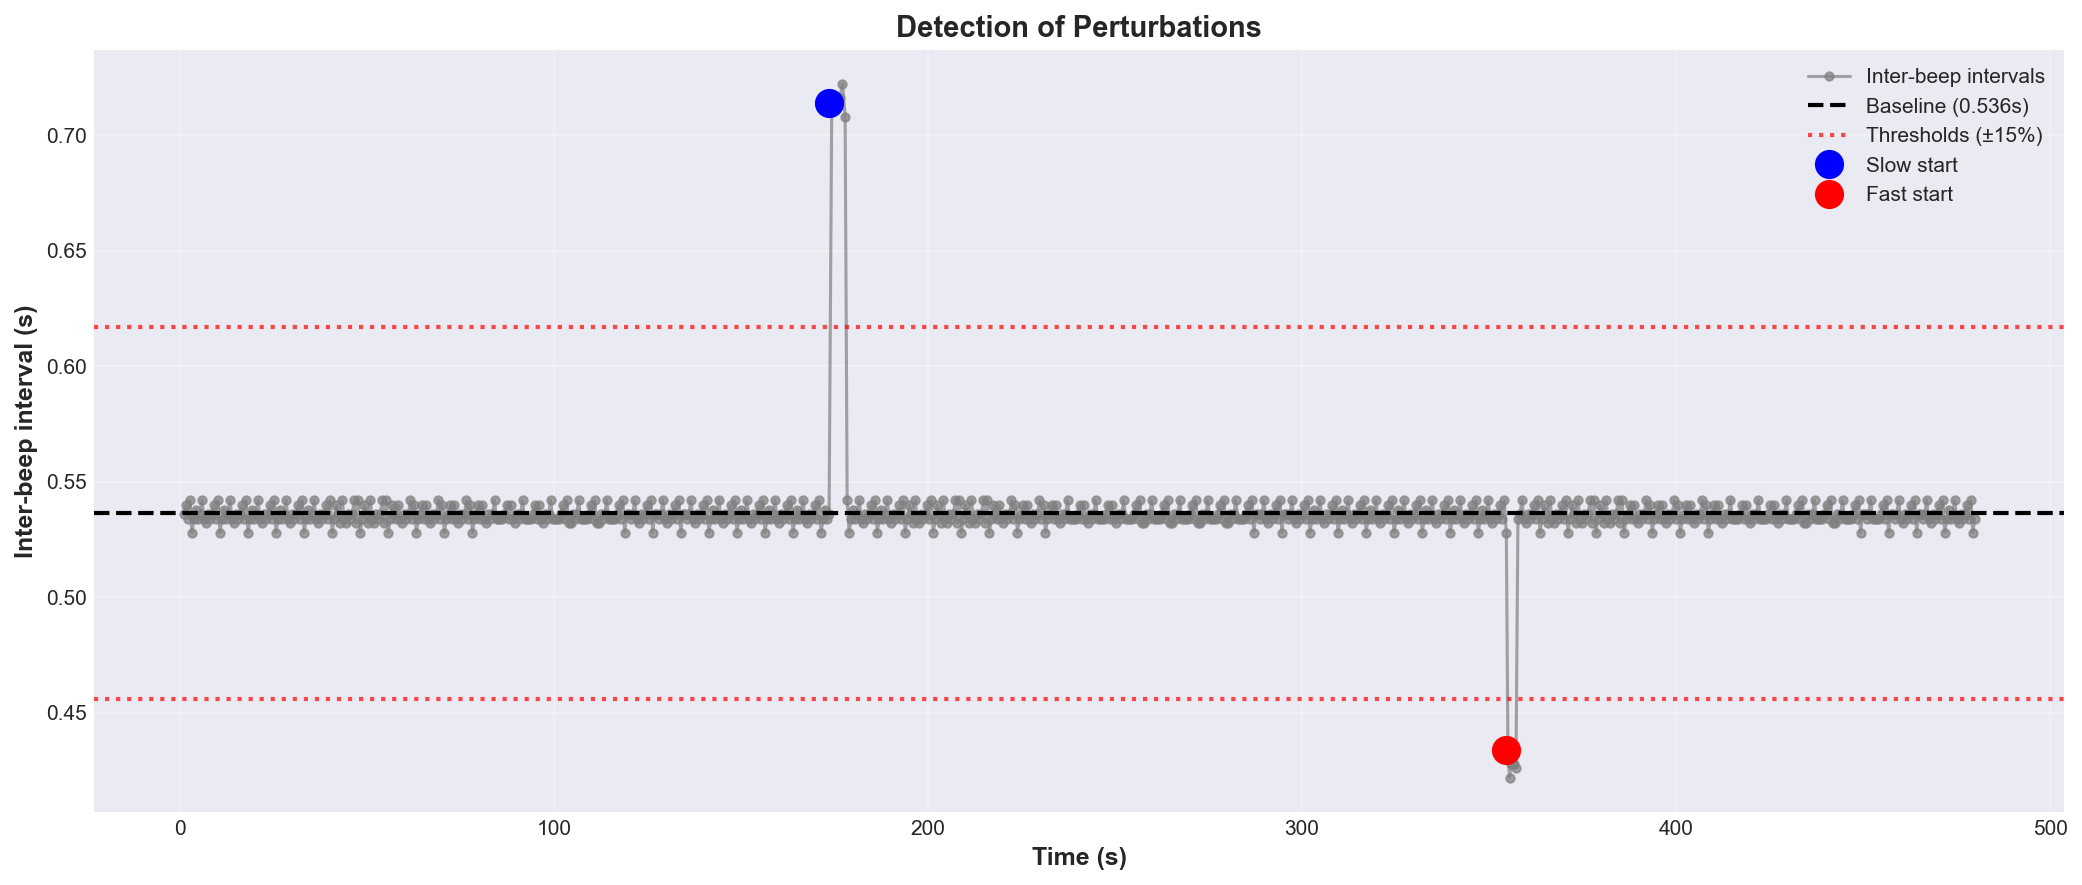

In [6]:
beep_times, _ = detect_beeps(data['analog']['value'], fs=data['analog']['fs'])
perturbations = detect_perturbations(beep_times)

print(f"\n✓ Perturbations:")
print(f"  Slow: {perturbations['slow_time']:.2f}s")
print(f"  Fast: {perturbations['fast_time']:.2f}s")

# Visualize perturbation detection
from perturbation_detection import plot_perturbation_detection

fig_pert = plot_perturbation_detection(
    beep_times, 
    perturbations,
    save_path='../results/figures/004_perturbation_detection.png'
)
plt.show()

In [7]:
if not np.isnan(perturbations['slow_time']) and not np.isnan(perturbations['fast_time']):
    baseline_end_time = min(perturbations['slow_time'], perturbations['fast_time']) - 10
elif not np.isnan(perturbations['slow_time']):
    baseline_end_time = perturbations['slow_time'] - 10
elif not np.isnan(perturbations['fast_time']):
    baseline_end_time = perturbations['fast_time'] - 10
else:
    baseline_end_time = 60

baseline_end_idx = int(baseline_end_time * fs)
reference = create_reference_trajectory(state_space, baseline_end_idx)

distances = compute_euclidean_distances(state_space, reference, phase_matching=False)

print(f"\n✓ Distances computed")
print(f"  Mean: {np.mean(distances):.2f} mm")
print(f"  Max: {np.max(distances):.2f} mm")

  Reference trajectory created from baseline:
    Baseline points: 16354
    Centroid: [0.60, 0.59, 0.59]
    Smoothing window: 50

✓ Distances computed
  Mean: 12.30 mm
  Max: 37.15 mm


In [8]:
baseline_mask = np.arange(len(distances)) < baseline_end_idx
thresholds = compute_torus_thresholds(distances, baseline_mask)

print(f"\n✓ Thresholds: T1={thresholds['T1']:.2f}, T2={thresholds['T2']:.2f}, T3={thresholds['T3']:.2f} mm")


  Torus thresholds computed:
    T1 (1σ): 21.93 mm - Very stable: 79.5%
    T2 (2σ): 30.93 mm - Stable: 19.9%
    T3 (3σ): 39.94 mm - Unstable: 0.7%
    >T3:     Very unstable: 0.0%

✓ Thresholds: T1=21.93, T2=30.93, T3=39.94 mm


In [9]:
steps, _ = find_peaks(-sacrum_z)
print(f"\n✓ Detected {len(steps)} steps")


✓ Detected 850 steps


In [10]:
metrics = compute_all_perturbation_metrics(
    distances=distances,
    thresholds=thresholds,
    perturbations=perturbations,
    step_indices=steps,
    fs=fs
)

print("\n" + "="*60)
print("RESILIENCE METRICS - P004")
print("="*60)
for name in ['slow', 'fast']:
    if name in metrics:
        m = metrics[name]
        print(f"\n{name.upper()}:")
        print(f"  Peak: {m['peak_value']:.2f} mm")
        print(f"  Recovery: {m['recovery_time']:.2f} s")
print("="*60)


COMPUTING RESILIENCE METRICS

[SLOW] Perturbation at t=173.54s
  Peak deviation: 26.42 mm at t=174.52s
  Recovery time: 0.00 s
  Steps to recovery: 0

[FAST] Perturbation at t=354.61s
  Peak deviation: 37.15 mm at t=356.83s
  Recovery time: 1.22 s
  Steps to recovery: 3



RESILIENCE METRICS - P004

SLOW:
  Peak: 26.42 mm
  Recovery: 0.00 s

FAST:
  Peak: 37.15 mm
  Recovery: 1.22 s


  Saved: ..\results\figures\004_tde_parameters.png
  Saved: ..\results\figures\004_recovery_curves.png

✓ Figures generated


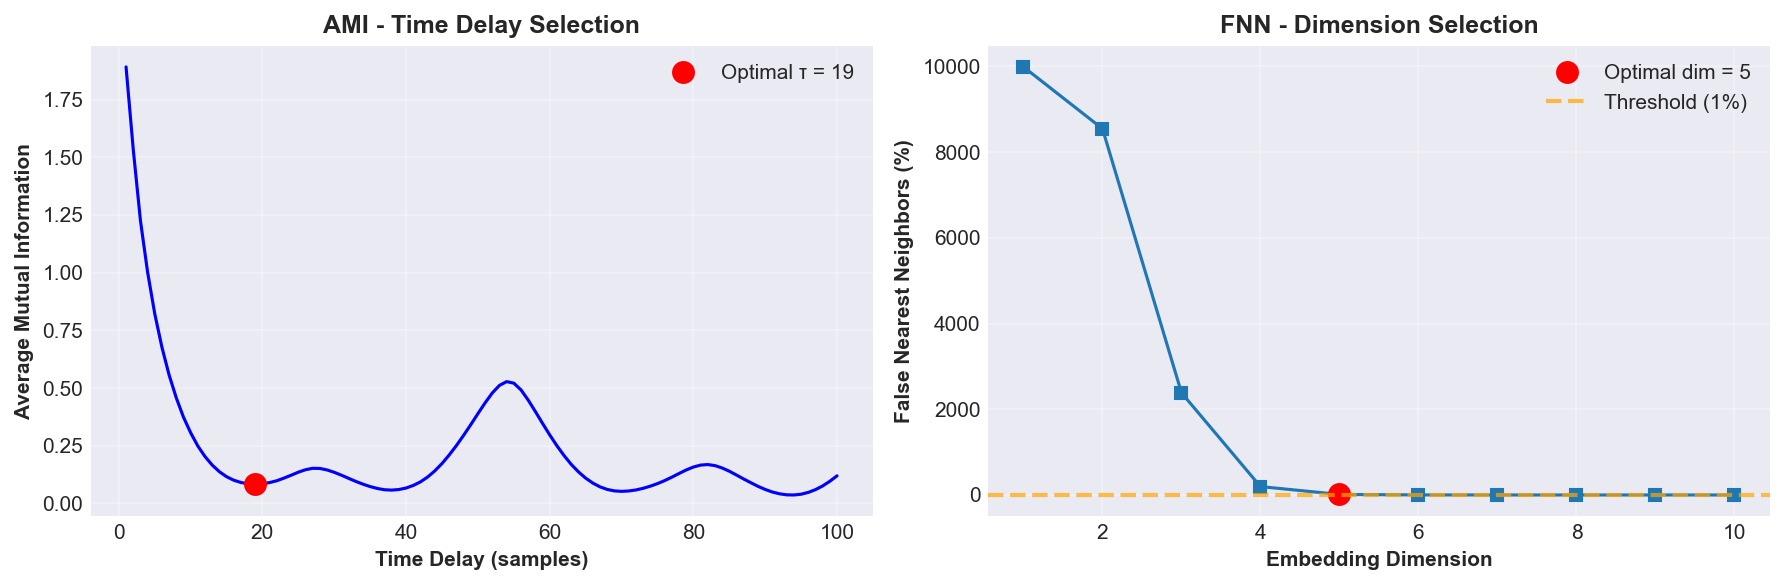

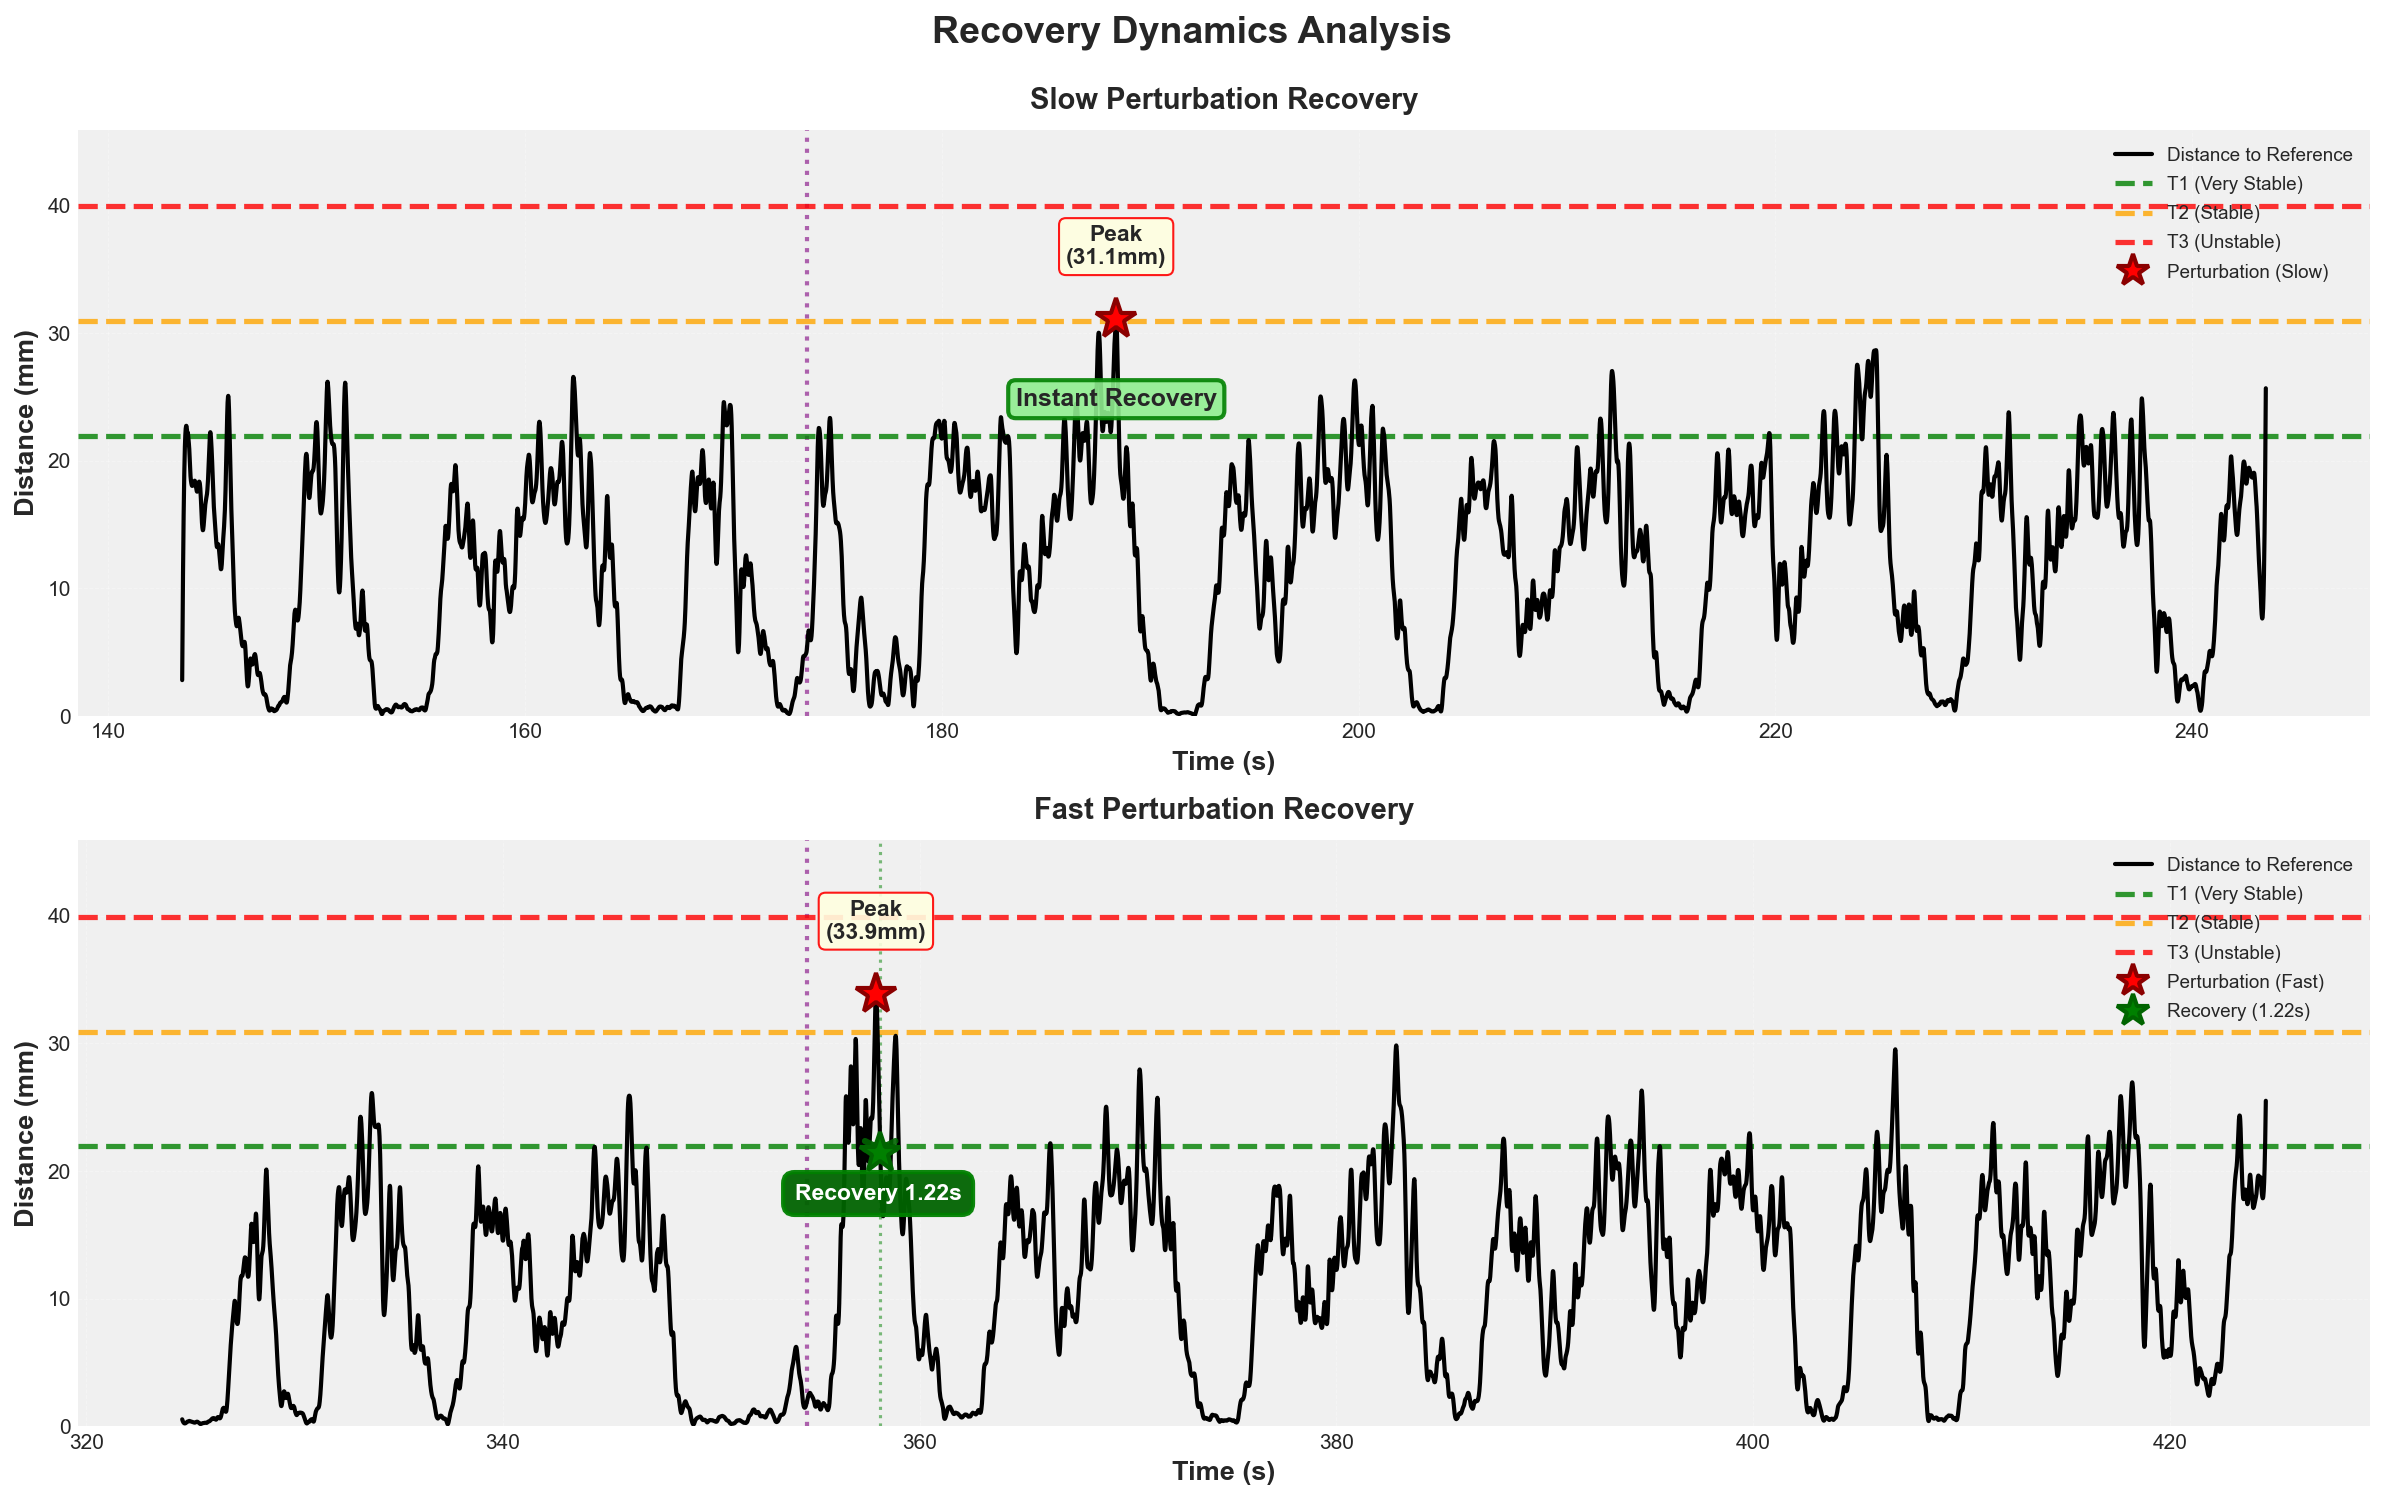

In [11]:
time_distances = np.arange(len(distances)) / fs

from visualization import plot_ami_fnn, plot_recovery_curves
from pathlib import Path

output_dir = Path('../results/figures')
output_dir.mkdir(parents=True, exist_ok=True)

plot_ami_fnn(ami_values, fnn_rates, tau_optimal, dim_optimal, 
             save_path=output_dir / '004_tde_parameters.png')

plot_recovery_curves(time_distances, distances, thresholds, perturbations, metrics,
                     save_path=output_dir / '004_recovery_curves.png')

print("\n✓ Figures generated")

In [13]:
summary = {
    'Participant': '004',
    'Group': 'Young',
    'Slow_Peak': metrics.get('slow', {}).get('peak_value', np.nan),
    'Slow_Recovery': metrics.get('slow', {}).get('recovery_time', np.nan),
    'Fast_Peak': metrics.get('fast', {}).get('peak_value', np.nan),
    'Fast_Recovery': metrics.get('fast', {}).get('recovery_time', np.nan),
}

df = pd.DataFrame([summary])
output_path = Path('../results/metrics/004_metrics.csv')
output_path.parent.mkdir(parents=True, exist_ok=True)
df.to_csv(output_path, index=False)

print(f"\n✓ Metrics saved: {output_path}")
print(df.to_string(index=False))


✓ Metrics saved: ..\results\metrics\004_metrics.csv
Participant Group  Slow_Peak  Slow_Recovery  Fast_Peak  Fast_Recovery
        004 Young  26.424571            0.0  37.150039           1.22
